# Introduction to Brian part 1: Neurons
Adapted from: https://brian2.readthedocs.io/en/stable/resources/tutorials/index.html

In [2]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

In [3]:
plt.rcParams.update({'font.size': 15, 'figure.figsize':[9,6]})

## Units system

In [4]:
print(20*volt)

20. V


In [5]:
print(1000*amp)

1. kA


In [6]:
print(1e6*volt)

1. MV


In [7]:
print(1000*namp)

1. uA


In [11]:
print(10*nA*5*Mohm)

50. mV


## A simple model

In [13]:
tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''
G = NeuronGroup(1, eqs)

### Running a simulation

In [10]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''
G = NeuronGroup(1, eqs)
run(100*ms)  # the run command

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/var/folders/_f/t5z2mynd5cg523nhd8bwyj980000gn/T/ipykernel_82165/2346472024.py', line 5, in <module>
    G = NeuronGroup(1, eqs) [brian2.core.base.unused_brian_object]
INFO       No numerical integration method specified for group 'neurongroup_1', using method 'exact' (took 0.01s). [brian2.stateupdaters.base.method_choice]


In [14]:
start_scope()

G = NeuronGroup(1, eqs, method='exact') # specify integration method

print('Before: v = {}'.format(G.v[0]))

run(100*ms)

print('After: v = {}'.format(G.v[0]))
print('Expected value of v = {}'.format(1-np.exp(-100*ms/tau)))

WARNING    The object 'neurongroup_2' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/var/folders/_f/t5z2mynd5cg523nhd8bwyj980000gn/T/ipykernel_82165/2346472024.py', line 5, in <module>
    G = NeuronGroup(1, eqs) [brian2.core.base.unused_brian_object]


Before: v = 0.0
After: v = 0.9999546000702376
Expected value of v = 0.9999546000702375


### Monitoring variables over time

<statemonitor.t: array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9,
       11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. ,
       12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1,
       13.2, 13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. , 14.1, 14.2,
       14.3, 14.4, 14.5, 14.6, 14.

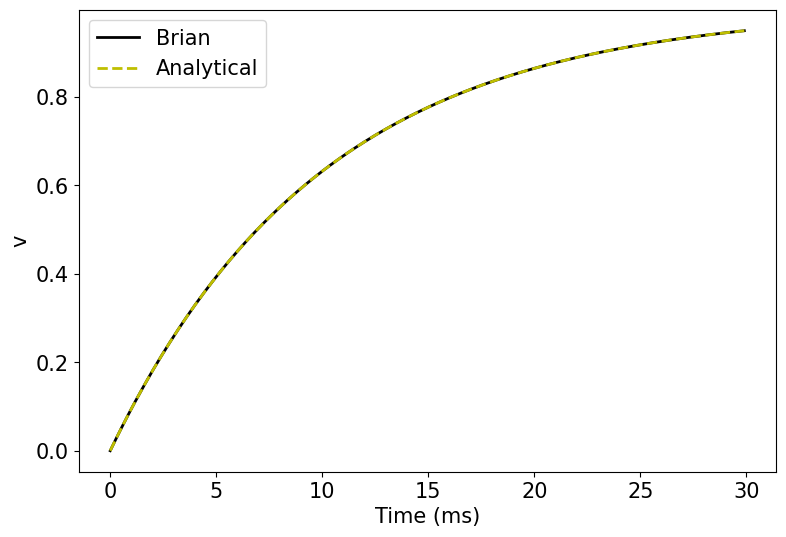

In [ ]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(1, eqs, method='exact')
M = StateMonitor(G, 'v', record=True)   # introducing a state monitor for neuron group G

run(30*ms)

plt.plot(M.t/ms, M.v[0], '-k', lw=2, label='Brian')
plt.plot(M.t/ms, 1-np.exp(-M.t/tau), '--y', lw=2, label='Analytical')
plt.xlabel('Time (ms)')
plt.ylabel('v')
plt.legend(loc='best');

### Adding more parameters

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/var/folders/_f/t5z2mynd5cg523nhd8bwyj980000gn/T/ipykernel_82165/935522889.py', line 5, in <module>
    G = NeuronGroup(1, eqs) [brian2.core.base.unused_brian_object]


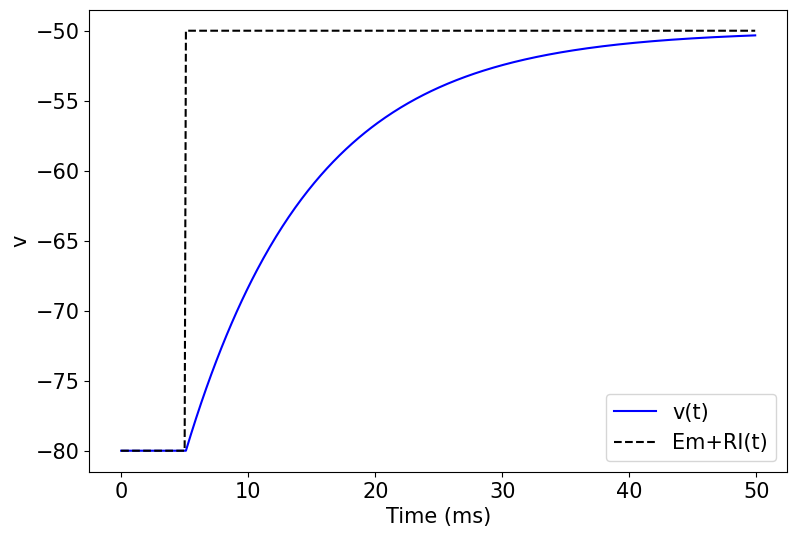

In [19]:
start_scope()

tau = 10*ms
E_leak = -80*mV
R = 1e7*ohm

eqs = '''
dv/dt = (-v + E_leak + R*I)/tau : volt
I = 3*nA*int(t>5*ms) : amp
'''

G = NeuronGroup(1, eqs, method='euler') 
M = StateMonitor(G, ('v', 'I'), record=True)

G.v = E_leak # initial value (default would be 0)

run(50*ms)

plt.plot(M.t/ms, M.v[0]/mV, 'b', label='v(t)')
plt.plot(M.t/ms, (E_leak + M.I[0]*R)/mV, 'k--', label='Em+RI(t)')
plt.xlabel('Time (ms)')
plt.ylabel('v')
plt.legend();

### EXERCISE: Use Brian to implement  Task 3b from sheet 4: 
Drive a passive membrane with a sinusoidal current: 
\begin{align*}
\tau\frac{dV}{dt} &= -V + E_m + RI(t) \\
I(t) &= I_0\sin(2\pi\nu t)
\end{align*}
with $\tau_m=10$ms, $E_m=-80$mV, $R=10^7\Omega$, $I_0 = 1$nA, $\nu=10$Hz. Use the initial value $V(0)=E_m$.

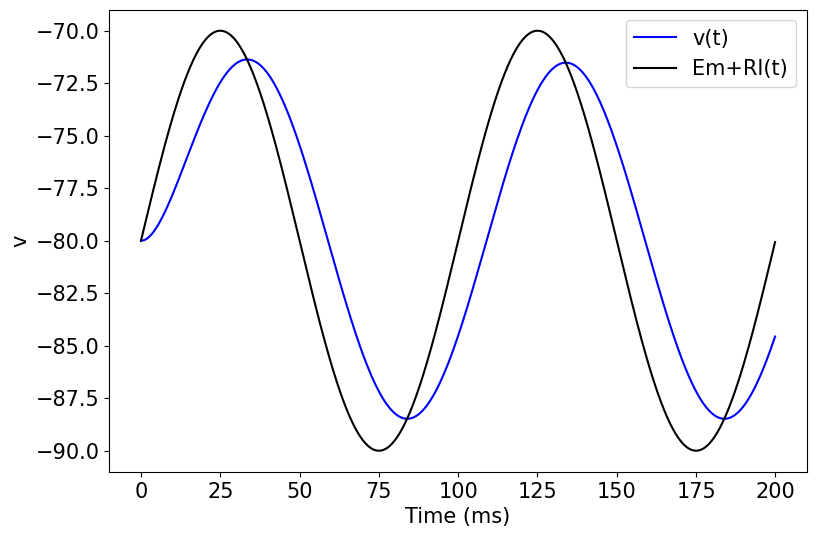

In [42]:
start_scope()

tau = 10*ms
IO = 1*nA
nu = 10*Hz
E_leak = -80*mV
R = 1e7*ohm

eqs = '''
dv/dt = (-v + E_leak + R*I)/tau : volt
I = IO * sin(2 * pi * nu * t) : amp
'''

G = NeuronGroup(1, eqs, method='euler') 
M = StateMonitor(G, ('v', 'I'), record=True) 

G.v = E_leak # initial value

run(200*ms)

plt.plot(M.t/ms, M.v[0]/mV, 'b', label='v(t)')  # plot membrane potential
plt.plot(M.t/ms, (E_leak + R * M.I[0])/mV, 'k', label='Em+RI(t)')  # plot rescaled input
plt.xlabel('Time (ms)')
plt.ylabel('v')
plt.legend();

## Adding spikes

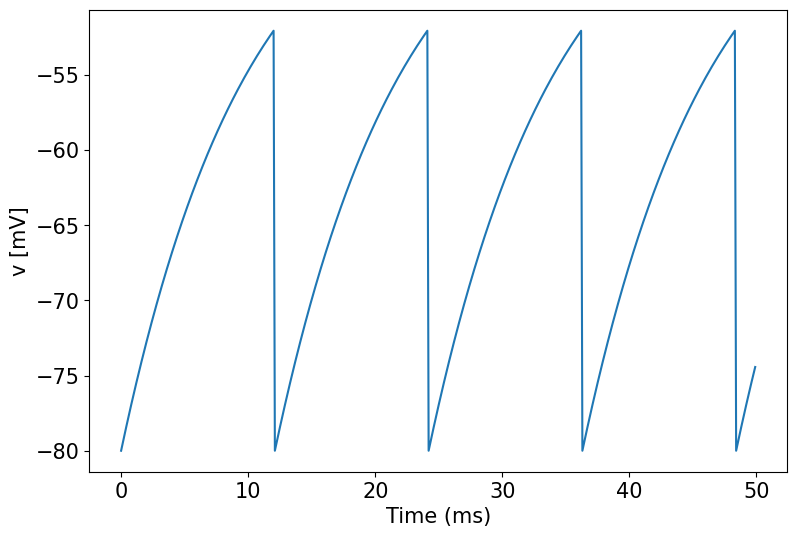

In [43]:
start_scope()

tau = 10*ms
E_leak = -80*mV
R = 1e7*ohm
Ie = 4*nA
Vthr = -52*mV
Vreset = -80*mV

eqs = '''
dv/dt = (-v + E_leak + R*Ie)/tau : volt
'''

G = NeuronGroup(1, eqs, method='exact', threshold='v>Vthr', reset='v = Vreset') # threshold and reset criteria
G.v = E_leak

M = StateMonitor(G, 'v', record=0)
run(50*ms)

plt.plot(M.t/ms, M.v[0]/mV)
plt.xlabel('Time (ms)')
plt.ylabel('v [mV]');

### Monitoring spikes

Spike times: [12.  24.1 36.2 48.3] ms


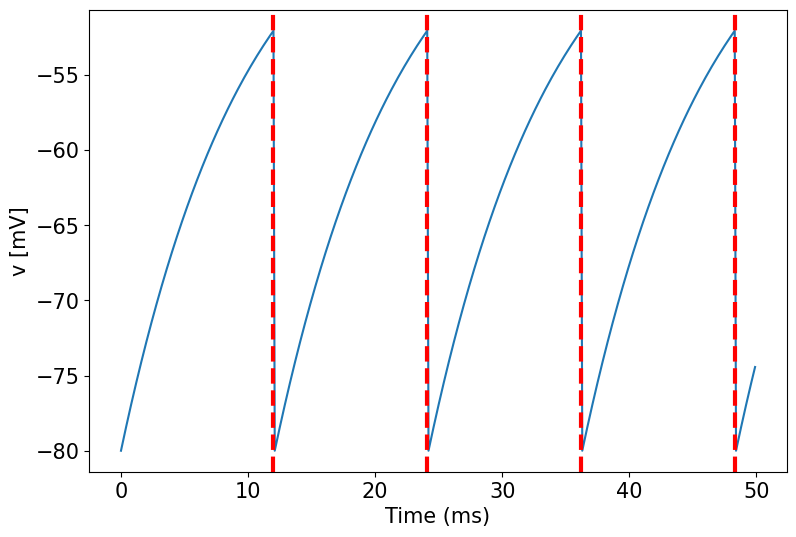

In [14]:
start_scope()

tau = 10*ms
E_leak = -80*mV
R = 1e7*ohm
Ie = 4*nA
Vthr = -52*mV
Vreset = -80*mV

eqs = '''
dv/dt = (-v + E_leak + R*Ie)/tau : volt
'''

G = NeuronGroup(1, eqs, method='exact', threshold='v>Vthr', reset='v = Vreset')
G.v = E_leak

M = StateMonitor(G, 'v', record=0)
spikemon = SpikeMonitor(G) # the spike monitor!

run(50*ms)

plt.plot(M.t/ms, M.v[0]/mV)
plt.xlabel('Time (ms)')
plt.ylabel('v [mV]');

print('Spike times: {}'.format(spikemon.t[:]))

for t in spikemon.t:
    plt.axvline(t/ms, ls='--', c='r', lw=3)

### Refractoriness

Spike times: [12. 29. 46.] ms


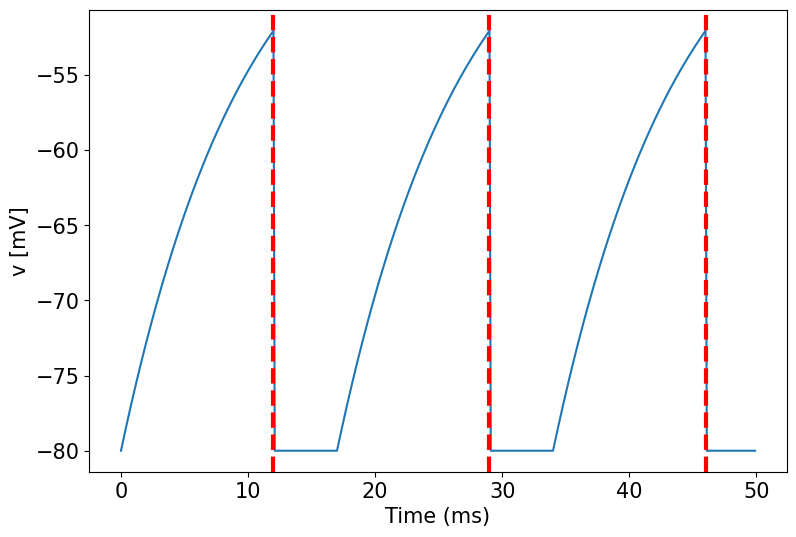

In [15]:
start_scope()

tau = 10*ms
E_leak = -80*mV
R = 1e7*ohm
Ie = 4*nA
Vthr = -52*mV
Vreset = -80*mV

eqs = '''
dv/dt = (-v + E_leak + R*Ie)/tau : volt (unless refractory)
'''

G = NeuronGroup(1, eqs, method='exact', threshold='v>Vthr', reset='v = Vreset', refractory=5*ms) # refractory period
G.v = E_leak

M = StateMonitor(G, 'v', record=0)
spikemon = SpikeMonitor(G)

run(50*ms)

plt.plot(M.t/ms, M.v[0]/mV)
plt.xlabel('Time (ms)')
plt.ylabel('v [mV]');

print('Spike times: {}'.format(spikemon.t[:]))

for t in spikemon.t:
    plt.axvline(t/ms, ls='--', c='r', lw=3)

## Multiple neurons

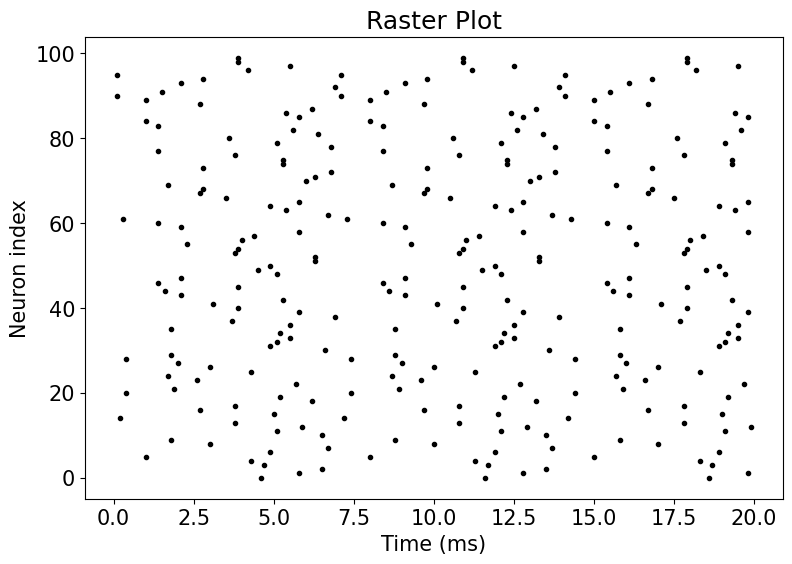

In [16]:
start_scope()
# seed(3)  # set seed for reproducibility!

N = 100
tau = 10*ms
eqs = '''
dv/dt = (2-v)/tau : 1
'''

G = NeuronGroup(N, eqs, method='exact', threshold='v>1', reset='v=0') # now N neurons
G.v = 'rand()' # random intial value between 0 and 1

spikemon = SpikeMonitor(G)

run(20*ms)

plt.plot(spikemon.t/ms, spikemon.i, '.k') # make raster plot
plt.ylabel('Neuron index')
plt.title('Raster Plot')
plt.xlabel('Time (ms)');

### EXERCISE:
add a StateMonitor to record and plot the voltage traces of neurons 0 and 43 !

WARNING    The object 'neurongroup_6' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/var/folders/_f/t5z2mynd5cg523nhd8bwyj980000gn/T/ipykernel_82165/3607149968.py', line 9, in <module>
    G = NeuronGroup(N, eqs, method='exact', threshold='v>1', reset='v=0') [brian2.core.base.unused_brian_object]


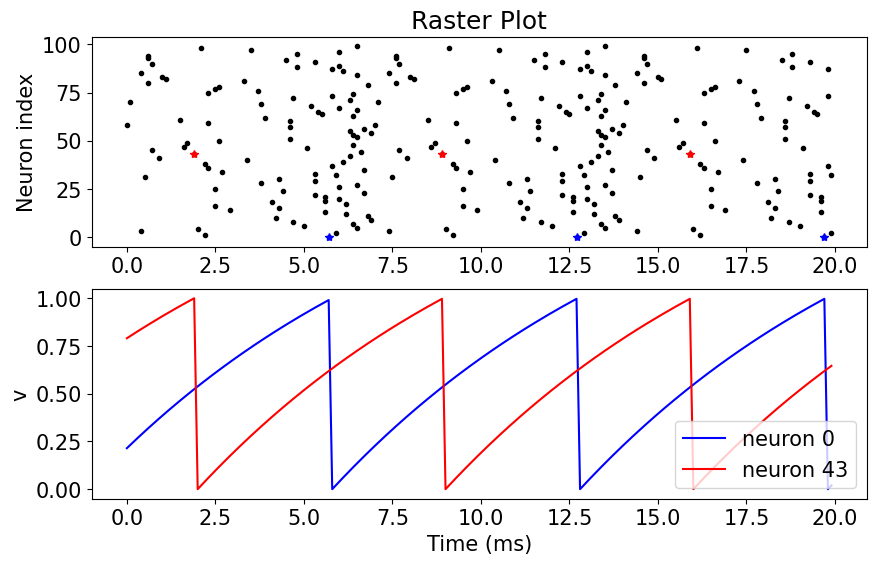

In [63]:
start_scope()

N = 100
tau = 10*ms
eqs = '''
dv/dt = (2-v)/tau : 1
'''

G = NeuronGroup(N, eqs, method='exact', threshold='v>1', reset='v=0')
G.v = 'rand()' # random intial value between 0 and 1

statemon = StateMonitor(source=G, record=[0, 43], variables='v') # save memory, record only few neurons
spikemon = SpikeMonitor(G)

run(20*ms)

plt.figure(figsize=(10,6))
plt.subplot(211)
plt.plot(spikemon.t/ms, spikemon.i, '.k')
plt.plot(spikemon.t[spikemon.i==0]/ms, spikemon.i[spikemon.i==0], '*b')
plt.plot(spikemon.t[spikemon.i==43]/ms, spikemon.i[spikemon.i==43], '*r')
plt.ylabel('Neuron index')
plt.title('Raster Plot')

plt.subplot(212)
plt.plot(statemon.t/ms, statemon.v[0], 'b', label='neuron 0')
plt.plot(statemon.t/ms, statemon.v[1], 'r', label='neuron 43')
plt.ylabel('v')
plt.xlabel('Time (ms)')
plt.legend();

### Monitoring population activity

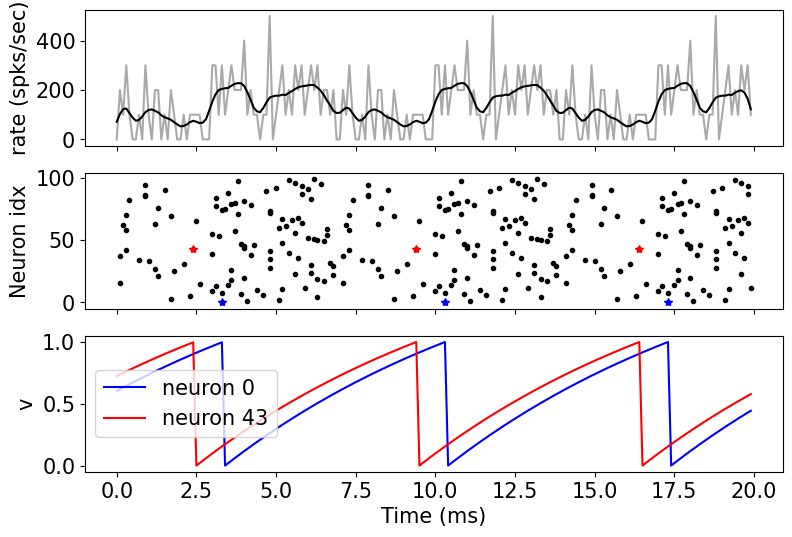

In [66]:
start_scope()

N = 100
tau = 10*ms
eqs = '''
dv/dt = (2-v)/tau : 1
'''

G = NeuronGroup(N, eqs, method='exact', threshold='v>1', reset='v=0')
G.v = 'rand()' 

statemon = StateMonitor(G, ('v'), record=[0,43]) 
spikemon = SpikeMonitor(G)
ratemon = PopulationRateMonitor(G) # record population rate

run(20*ms)

fig, ax = plt.subplots(3, sharex=True)
# plot population rate
ax[0].plot(ratemon.t/ms, ratemon.rate/Hz, 'darkgrey')
ax[0].plot(ratemon.t/ms, ratemon.smooth_rate(width=.2*ms)/Hz, 'k')
ax[0].set_ylabel('rate (spks/sec)')

ax[1].plot(spikemon.t/ms, spikemon.i, '.k')
ax[1].plot(spikemon.t[spikemon.i==0]/ms, spikemon.i[spikemon.i==0], '*b')
ax[1].plot(spikemon.t[spikemon.i==43]/ms, spikemon.i[spikemon.i==43], '*r')
ax[1].set_ylabel('Neuron idx')

ax[2].plot(statemon.t/ms, statemon.v[0], 'b', label='neuron 0')
ax[2].plot(statemon.t/ms, statemon.v[1], 'r', label='neuron 43')
ax[2].set_ylabel('v')
ax[2].set_xlabel('Time (ms)')
ax[2].legend();

### Varying parameters across neurons

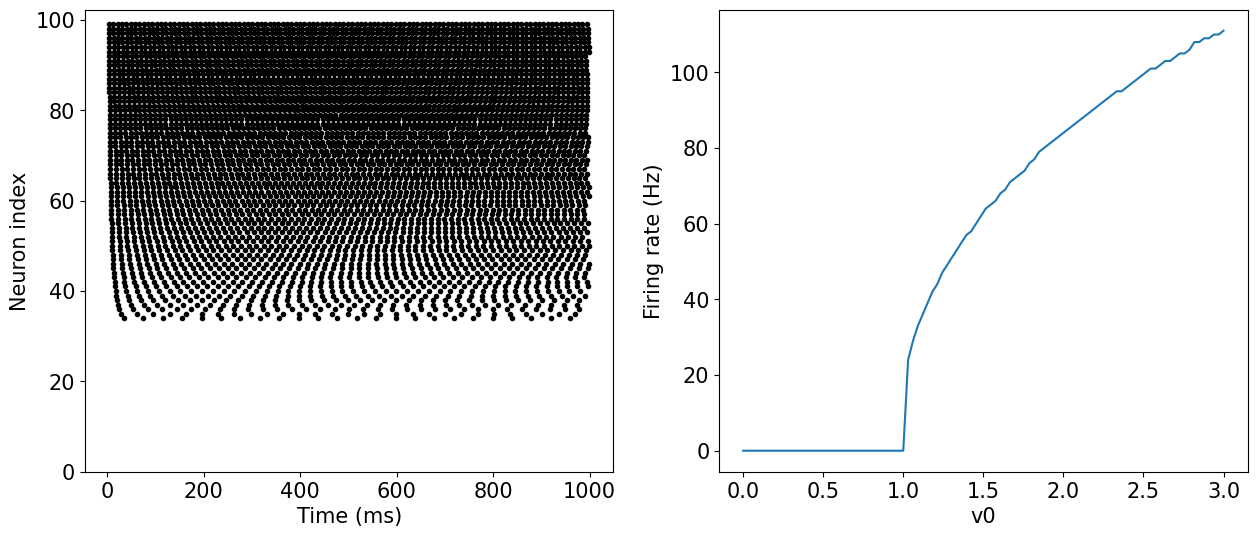

In [69]:
start_scope()

N = 100
tau = 10*ms
v0_max = 3.
duration = 1000*ms

eqs = '''
dv/dt = (v0-v)/tau : 1 (unless refractory)
v0 : 1
'''

G = NeuronGroup(N, eqs, method='exact', threshold='v>1', reset='v=0', refractory=5*ms)
M = SpikeMonitor(G)

G.v0 = 'v0_max*i/(N-1)' # leak potential depends on neuron index i, ranges from 0 to v0_max

run(duration)

plt.figure(figsize=(15,6))
plt.subplot(121)
plt.plot(M.t/ms, M.i, '.k')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.ylim(bottom=0)
plt.subplot(122)
plt.plot(G.v0, M.count/duration)
plt.xlabel('v0')
plt.ylabel('Firing rate (Hz)');

# Introduction to Brian part 2: Synapses
Adapted from: https://brian2.readthedocs.io/en/stable/resources/tutorials/index.html

## The simplest Synapse

WARNING    'tau' is an internal variable of group 'neurongroup_1', but also exists in the run namespace with the value 10. * msecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


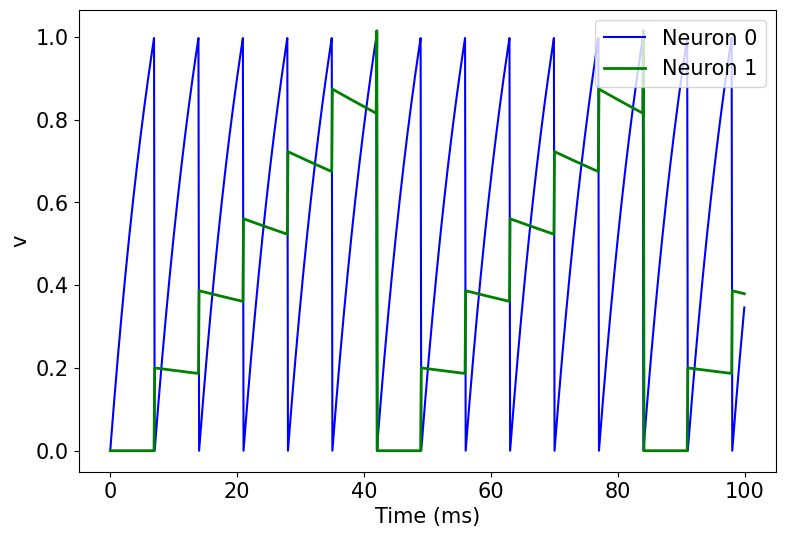

In [70]:
start_scope()

eqs = '''
dv/dt = (I-v)/tau : 1
I : 1
tau : second
'''
G = NeuronGroup(2, eqs, method='exact', threshold='v>1', reset='v = 0')
G.I = [2, 0]
G.tau = [10, 100]*ms

# Comment these two lines out to see what happens without Synapses
S = Synapses(G, G, on_pre='v_post += 0.2')
S.connect(i=0, j=1)

M = StateMonitor(G, 'v', record=True)

run(100*ms)

plt.plot(M.t/ms, M.v[0], '-b', label='Neuron 0')
plt.plot(M.t/ms, M.v[1], '-g', lw=2, label='Neuron 1')
plt.xlabel('Time (ms)')
plt.ylabel('v')
plt.legend(loc='upper right');

## Adding a weight

WARNING    'tau' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value 10. * msecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


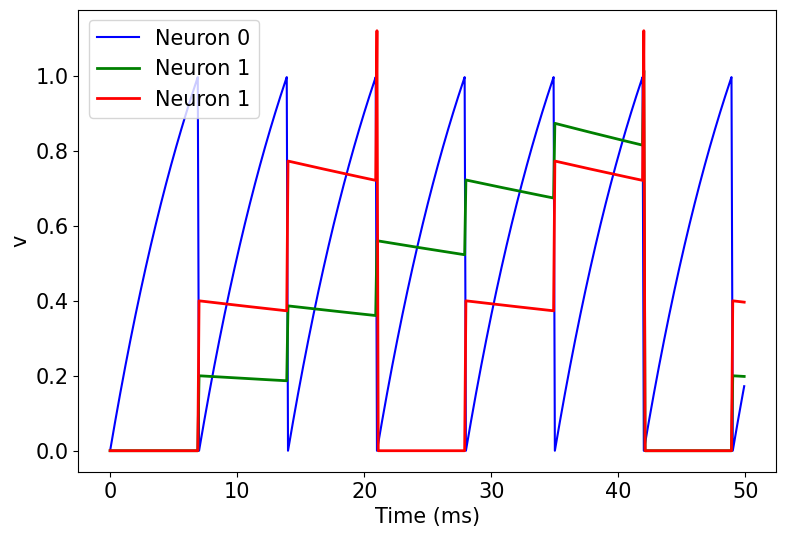

In [20]:
start_scope()

eqs = '''
dv/dt = (I-v)/tau : 1
I : 1
tau : second
'''
G = NeuronGroup(3, eqs, method='exact', threshold='v>1', reset='v = 0')
G.I = [2, 0, 0]
G.tau = [10, 100, 100]*ms

# Comment these two lines out to see what happens without Synapses
S = Synapses(G, G, 'w : 1', on_pre='v_post += w') # synapse now has a weight parameter w
S.connect(i=0, j=[1, 2]) # neuron 0 projects to neurons 1 and 2
S.w = 'j*0.2' # weight depends on postsynaptic neuron index j

M = StateMonitor(G, 'v', record=True)

run(50*ms)

plt.plot(M.t/ms, M.v[0], '-b', label='Neuron 0')
plt.plot(M.t/ms, M.v[1], '-g', lw=2, label='Neuron 1')
plt.plot(M.t/ms, M.v[2], '-r', lw=2, label='Neuron 1')
plt.xlabel('Time (ms)')
plt.ylabel('v')
plt.legend(loc='best');

## Introducing a delay

WARNING    'tau' is an internal variable of group 'neurongroup_3', but also exists in the run namespace with the value 10. * msecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


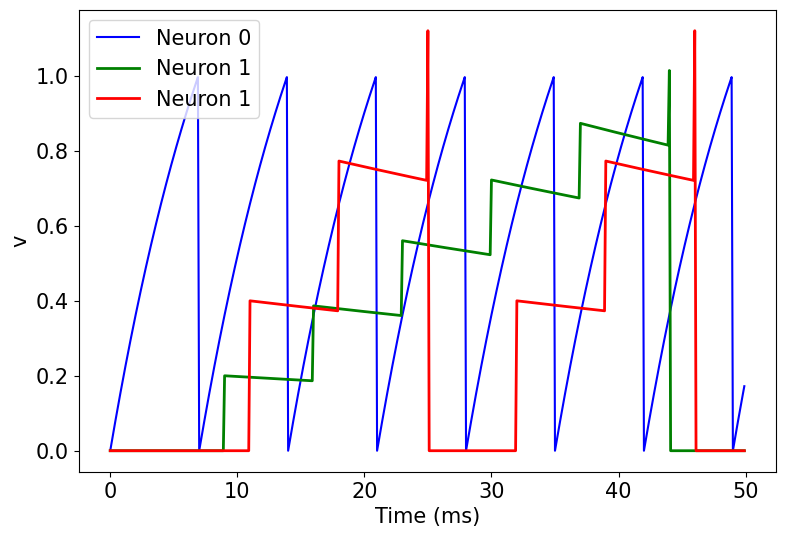

In [71]:
start_scope()

eqs = '''
dv/dt = (I-v)/tau : 1
I : 1
tau : second
'''
G = NeuronGroup(3, eqs, method='exact', threshold='v>1', reset='v = 0')
G.I = [2, 0, 0]
G.tau = [10, 100, 100]*ms

# Comment these two lines out to see what happens without Synapses
S = Synapses(G, G, 'w : 1', on_pre='v_post += w')
S.connect(i=0, j=[1, 2])
S.w = 'j*0.2'
S.delay = 'j*2*ms' # delay depends on postsyn neuron index j

M = StateMonitor(G, 'v', record=True)

run(50*ms)

plt.plot(M.t/ms, M.v[0], '-b', label='Neuron 0')
plt.plot(M.t/ms, M.v[1], '-g', lw=2, label='Neuron 1')
plt.plot(M.t/ms, M.v[2], '-r', lw=2, label='Neuron 1')
plt.xlabel('Time (ms)')
plt.ylabel('v')
plt.legend(loc='best');

## Exercise:
Implement exercise 1 from sheet 5 using Brian:
\begin{align*}
\frac{dV}{dt} &= \big(-V(t) + E_m - R_mI_\mathrm{syn}(t)\big)/\tau_m \\
I_\mathrm{syn}(t) &= g(t)\big(V-E_\mathrm{exc}\big)\\
\frac{dg}{dt} &= \big(x(t) - g(t)\big)/\tau_\mathrm{syn} \\
\frac{dx}{dt} &= -x(t)/\tau_\mathrm{syn} + g^\star\delta(t-t_\mathrm{spk}) \\
\end{align*}
with
$\tau_m=\tau_\mathrm{syn}=10$ms, $g^\star=30$ nS, $R_m=10^7\Omega$, $E_m=-80$mV, $E_\mathrm{exc}=0$mV.  

In [1]:
start_scope()

tm = 10*ms
Em = -80*mV
R = 1e7*ohm
tsyn = 10*ms
Ee = 0*mV

eqs = '''
dv/dt = (-v+Em-R*Isyn)/tm : volt 
Isyn  = g * (v - Ee) : amp
dg/dt = (x - g) / tsyn: siemens
dx/dt = -1 * x / tsyn: siemens
'''

G = NeuronGroup(1, eqs, method='euler')
G.v = Em
M = StateMonitor(source=G, record=True, variables=['v', 'g', 'x'])

# sending a single input spike:
indices = np.array([0]) # index of neuron(s) that will fire
times = np.array([5])*ms # times at which neuron(s) fire
# sending two input spikes:
# indices, times = np.zeros(2), np.array([5,15])*ms 
inp = SpikeGeneratorGroup(1, indices, times)

eqs_syn   = 'gstar: siemens'
eqs_onpre = 'x += gstar'

S= Synapses(inp, G, eqs_syn, on_pre = eqs_onpre)
S.connect()
S.gstar = 30*nS

run(120*ms)

# plot
plt.figure(figsize=(8,6))
plt.subplot(311)
plt.plot(M.t/ms, M.v[0]/mV)
plt.ylabel('v (mV)')

plt.subplot(312)
plt.plot(M.t/ms, M.g[0]/nS)
plt.ylabel('g (nS)')

plt.subplot(313)
plt.plot(M.t/ms, M.x[0]/nS)
plt.ylabel('x (nS)');

NameError: name 'start_scope' is not defined

## More complex connectivity
### random connectivity

In [88]:
start_scope()

N = 10
G = NeuronGroup(N, 'v:1')
S = Synapses(G, G)
S.connect(p=0.2) # specify a connection probability

AxisError: axis 10 is out of bounds for array of dimension 0

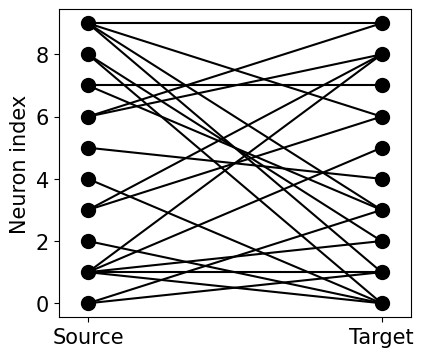

In [89]:
def visualise_connectivity(S):
    Ns = len(S.source)
    Nt = len(S.target)
    plt.figure(figsize=(10, 4))
    plt.subplot(121)
    plt.plot(np.zeros(Ns), np.arange(Ns), 'ok', ms=10)
    plt.plot(np.ones(Nt), np.arange(Nt), 'ok', ms=10)
    for i, j in zip(S.i, S.j):
        plt.plot([0, 1], [i, j], '-k')
    plt.xticks([0, 1], ['Source', 'Target'])
    plt.ylabel('Neuron index')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-1, max(Ns, Nt))
    plt.subplot(122)
    plt.plot(S.i, S.j, 'ok')
    plt.xlim(-1, Ns)
    plt.ylim(-1, Nt)
    plt.xlabel('Source neuron index')
    plt.ylabel('Target neuron index');
    
visualise_connectivity(S)

Varying connection probability

AxisError: axis 10 is out of bounds for array of dimension 0

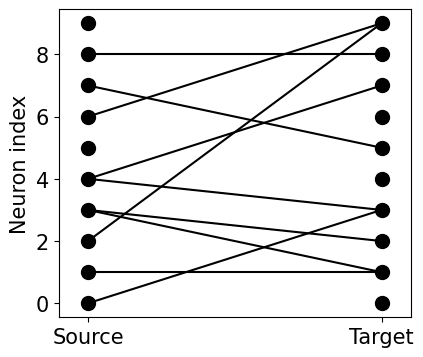

In [90]:
start_scope()

N = 10
G = NeuronGroup(N, 'v:1')

for p in [0.1, 0.5, 1.0]:
    S = Synapses(G, G)
    S.connect(p=p)
    visualise_connectivity(S)
    plt.suptitle('p = '+str(p))

### Connectivity conditions

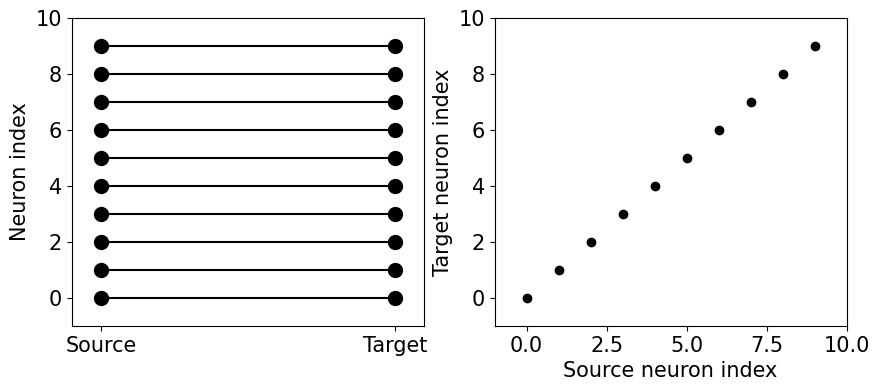

In [25]:
start_scope()

N = 10
G = NeuronGroup(N, 'v:1')

S = Synapses(G, G)
S.connect(condition='i==j')  # which neurons will be connected?
visualise_connectivity(S)

### EXERCISE
Connect each neuron to its (maximally) 4 nearest neighbors (the 2 neurons with lower and larger indices resp.), but NOT to itself (no autapses).

example: neuron 6 is connected to neurons 4,5,7 and 8.

AxisError: axis 10 is out of bounds for array of dimension 0

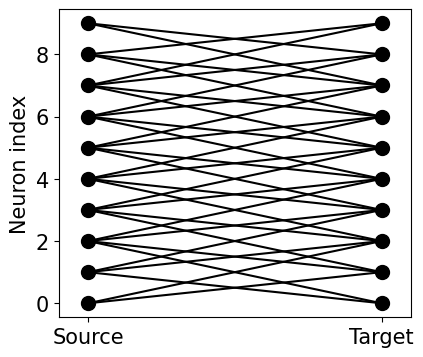

In [91]:
start_scope()

N = 10
G = NeuronGroup(N, 'v:1')

S = Synapses(G, G)
S.connect(condition='i==j-1 or i==j-2 or i==j+1 or i==j+2') 
visualise_connectivity(S)

### distance-dependent connectivity

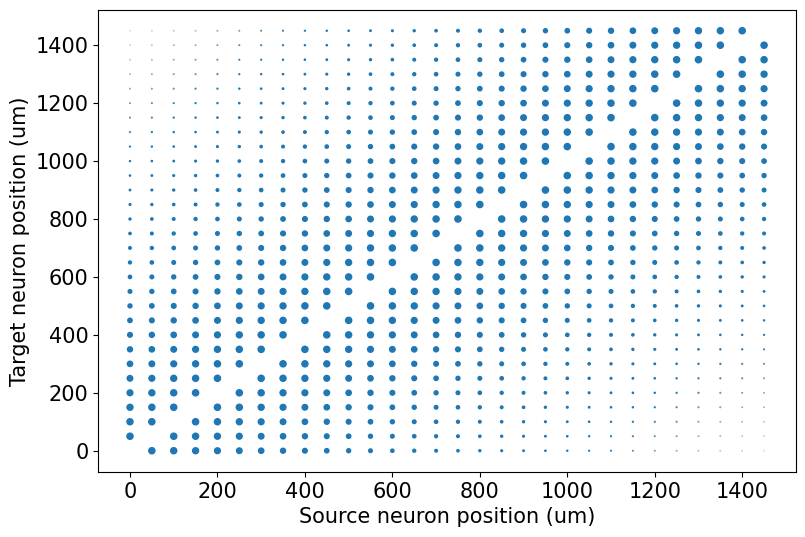

In [26]:
start_scope()

N = 30
neuron_spacing = 50*umetre
width = N/4.0*neuron_spacing

# Neuron has one variable x, its position
G = NeuronGroup(N, 'x : metre')
G.x = 'i*neuron_spacing' # neurons arranged on a 1D line, equally spaced

# All synapses are connected (excluding self-connections)
S = Synapses(G, G, 'w : 1')
S.connect(condition='i!=j')
# Weight varies with distance
S.w = 'exp(-(x_pre-x_post)**2/(2*width**2))'

# plot synaptic weights depending on neuron position
plt.scatter(G.x[S.i]/um, G.x[S.j]/um, S.w*20)
plt.xlabel('Source neuron position (um)')
plt.ylabel('Target neuron position (um)');

# Final remark: There are many network simulators

-- NEST (https://www.nest-simulator.org/)

-- Brian (https://brian2.readthedocs.io)

-- Neuron / NetPyNe (http://www.netpyne.org/)

for a comparison see also: 
Tikidji-Hamburyan et al., Software for brain network simulations: A comparative study, 2017 (available on moodle)

# Extra exercise: 
Convince yourself that the double-exponential postsynaptic potential 
\begin{align}
g(t) &= g_\mathrm{peak}s\left[e^{-t/\tau_d} - e^{-t/\tau_r}\right]\Theta(t)
\end{align}
is implemented with the following ODEs:
\begin{align*}
\dot{g}(t) &= \left(-g+x\right)/\tau_d \\
\dot{x}(t) &= -x/\tau_r \\
x(0) &= g_\mathrm{peak}s\frac{\tau_d - \tau_r}{\tau_r}\quad\text{ initial value}
\end{align*}
Here it has been assumed that the input spike arrives at time 0. The peak conductance is given by $g_\mathrm{peak}$, which is ensured by the normalizing factor 
\begin{align*}
s &= \left(\text{max}\left(e^{-t/\tau_d} - e^{-t/\tau_r}\right)\right)^{-1}
= \left(\left(\frac{\tau_d}{\tau_r}\right)^{\frac{\tau_r}{\tau_r-\tau_d}}- \left(\frac{\tau_d}{\tau_r}\right)^{\frac{\tau_d}{\tau_r-\tau_d}}\right)^{-1}
\end{align*}
Rise and decay time constants are given by $\tau_r$ and $\tau_d$ resp.

a) Starting from the equation for $g(t)$, derive the ODEs analytically. 

b) Use the ODEs to implement a double-exponential synapse in Brian and send an input spike to test the shape of the postsynaptic potential. Example parameter set: $\tau_r=1$ms, $\tau_d$=4ms, $g_\mathrm{peak}$=11nS.

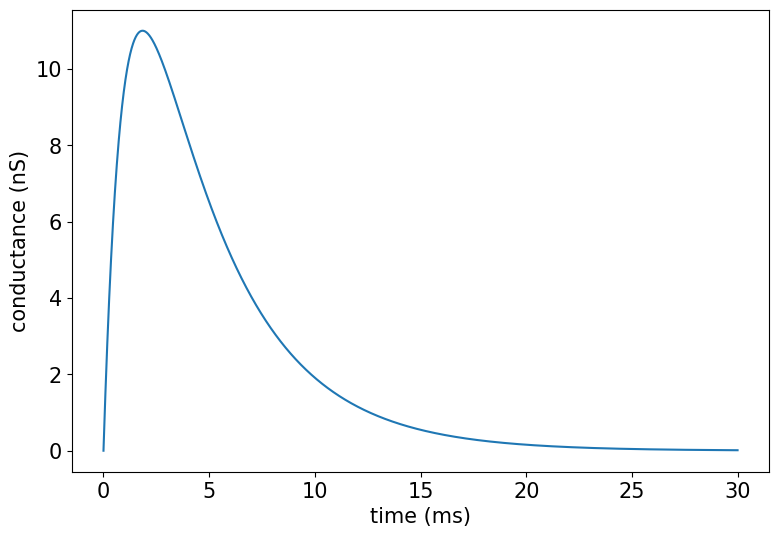

In [27]:
dt = .01
t = np.arange(0,30,dt)
tr, td, gpeak = 1, 4, 11
s = 1/((td/tr)**(tr/(tr-td)) - (td/tr)**(td/(tr-td)))
g = gpeak*s*(np.exp(-t/td) - np.exp(-t/tr))

plt.plot(t, g)
plt.xlabel('time (ms)')
plt.ylabel('conductance (nS)');

## beyond tutorial: 

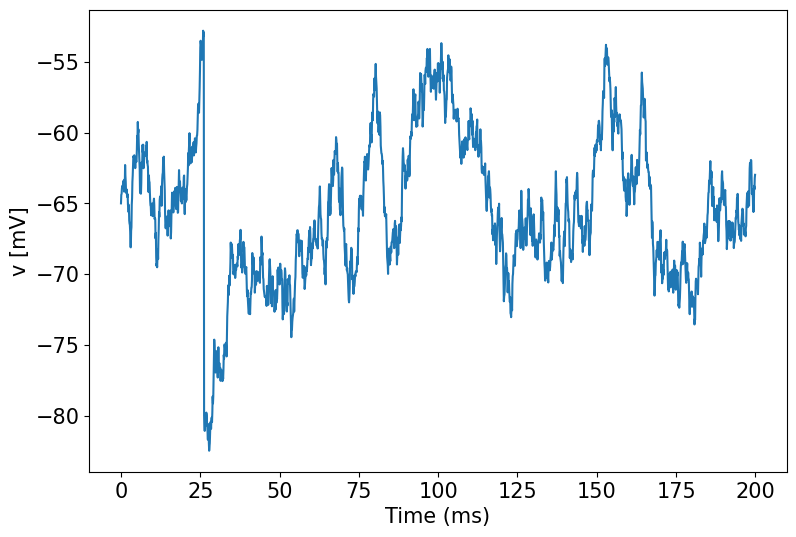

In [28]:
start_scope()

tau = 10*ms
E_leak = -65*mV
Ie = 4*nA
Vthr = -52*mV
Vreset = -80*mV
sig_v = 5*mV
C= 100*pfarad
sig_I = sig_v*C

eqs = '''
dv/dt = (-v + E_leak)/tau + sqrt(2/tau)*sig_v*xi : volt
'''

G = NeuronGroup(1, eqs, method='heun', threshold='v>Vthr', reset='v = Vreset') # threshold and reset criteria
G.v = E_leak

M = StateMonitor(G, 'v', record=0)
run(200*ms)

plt.plot(M.t/ms, M.v[0]/mV)
plt.xlabel('Time (ms)')
plt.ylabel('v [mV]');

In [29]:
# no index: error if xi is outside of SDE
start_scope()
seed(2)

tau = 10*ms
E_leak = -65*mV
Ie = 4*nA
Vthr = -52*mV
Vreset = -80*mV
sig_v = 5*mV
C= 100*pfarad
sig_I = sig_v*C

eqs = '''
dv/dt = (-v + E_leak)/tau + X : volt
X = sqrt(2/tau)*sig_v*xi : volt/second
'''

G = NeuronGroup(1, eqs, method='heun', threshold='v>Vthr', reset='v = Vreset') # threshold and reset criteria
G.v = E_leak

M = StateMonitor(G, 'v', record=0)
run(200*ms)

plt.plot(M.t/ms, M.v[0]/mV)
plt.xlabel('Time (ms)')
plt.ylabel('v [mV]');

EquationError: The equation defining 'X' contains the symbol 'xi' but is not a differential equation.

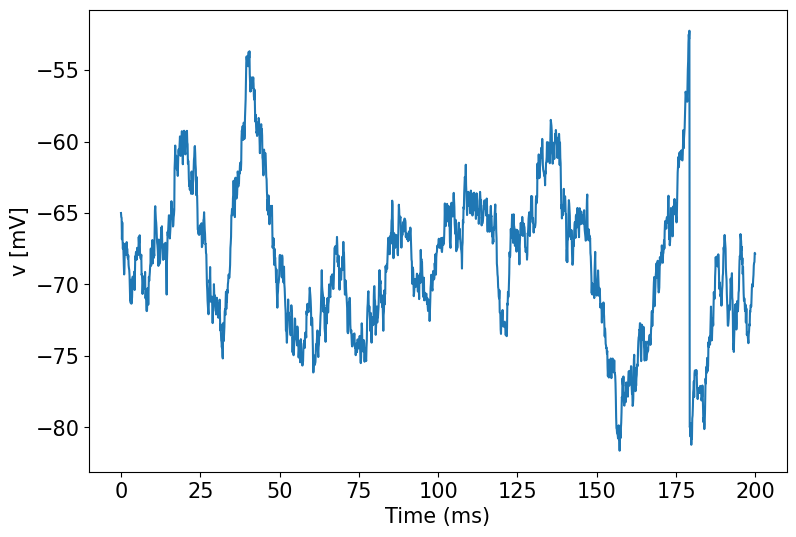

In [30]:
# with index ok and yields same result as within SDE
start_scope()
seed(2)

tau = 10*ms
E_leak = -65*mV
Ie = 4*nA
Vthr = -52*mV
Vreset = -80*mV
sig_v = 5*mV
C= 100*pfarad
sig_I = sig_v*C

eqs = '''
dv/dt = (-v + E_leak)/tau + X : volt
X = sqrt(2/tau)*sig_v*xi_indep : volt/second
'''

G = NeuronGroup(1, eqs, method='heun', threshold='v>Vthr', reset='v = Vreset') # threshold and reset criteria
G.v = E_leak

M = StateMonitor(G, 'v', record=0)
run(200*ms)

plt.plot(M.t/ms, M.v[0]/mV)
plt.xlabel('Time (ms)')
plt.ylabel('v [mV]');

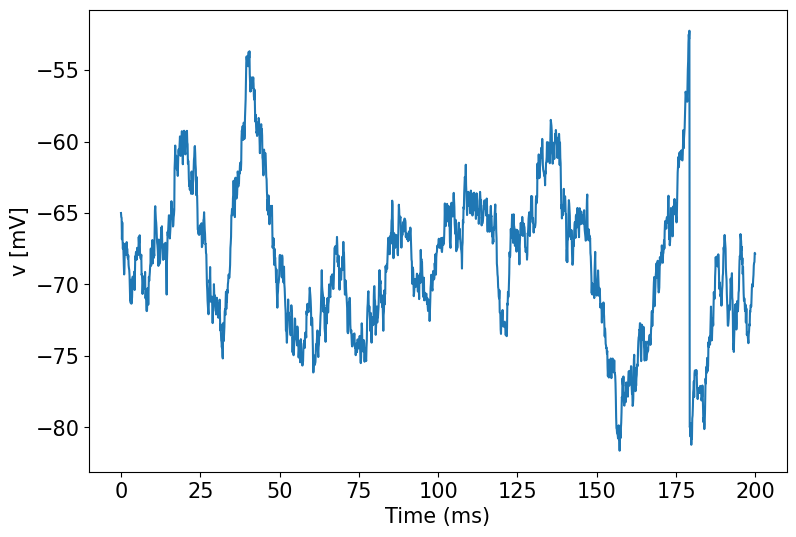

In [31]:
start_scope()
seed(2)

tau = 10*ms
E_leak = -65*mV
Ie = 4*nA
Vthr = -52*mV
Vreset = -80*mV
sig_v = 5*mV
C= 100*pfarad
sig_I = sig_v*C

eqs = '''
dv/dt = (-v + E_leak)/tau + sqrt(2/tau)*sig_v*xi_indep : volt
'''

G = NeuronGroup(1, eqs, method='heun', threshold='v>Vthr', reset='v = Vreset') # threshold and reset criteria
G.v = E_leak

M = StateMonitor(G, 'v', record=0)
run(200*ms)

plt.plot(M.t/ms, M.v[0]/mV)
plt.xlabel('Time (ms)')
plt.ylabel('v [mV]');